In [1]:
import pandas as pd
import numpy as np
import re

## Time benchmarks

In [2]:
# open the npy file
time_fl = np.load('results/benchmarks_fl.npy', allow_pickle=True).item()

In [3]:

for k, v in time_fl.items():
    print(k, ":", np.round(np.mean(v), 4), np.round(np.std(v), 4))

fl_25_tomopy_fbp_gpu_stride-1 : 1.6 0.0055
fl_25_tomopari_fbp_gpu_stride-1 : 0.5351 0.1587
fl_25_tomopari_fbp_cpu_stride-100 : 0.1716 0.0013
fl_25_tomopari_tomodl_gpu_stride-100 : 6.8864 0.0753
fl_25_tomopari_tomodl_cpu_stride-100 : 142.1295 15.4684
fl_25_tomopy_sart_gpu_stride-100 : 2.1538 0.2003
fl_50_tomopy_fbp_gpu_stride-1 : 1.8142 0.0406
fl_50_tomopari_fbp_gpu_stride-1 : 0.7421 0.1889
fl_50_tomopari_fbp_cpu_stride-100 : 0.3381 0.0009
fl_50_tomopari_tomodl_gpu_stride-100 : 6.307 0.0371
fl_50_tomopari_tomodl_cpu_stride-100 : 87.8464 3.3093
fl_50_tomopy_sart_gpu_stride-100 : 2.2481 0.2811
fl_400_tomopy_fbp_gpu_stride-1 : 7.6422 0.0825
fl_400_tomopy_sart_gpu_stride-100 : 2.0535 0.0295


In [4]:
_STEPS_TO_LABEL = {'400': '1x', '200': '2x', '100': '4x', '50': '8x', '25': '16x'}

def extract_timing(bdict: dict, modality: str, method_pattern: str,
steps_to_label: dict | None = None) -> dict:
    """Return {label: (mean, std)} for keys matching modality and method_pattern.
    Values are scaled by the stride factor embedded in the key (stride-N → multiply by N).
    steps_to_label maps step-count strings to display labels; defaults to _STEPS_TO_LABEL.
    """
    if steps_to_label is None:
        steps_to_label = _STEPS_TO_LABEL
    stride_re = re.compile(r'stride-(\d+)')
    raw: dict[str, tuple] = {}
    for key, values in bdict.items():
        tokens = key.split('_')
        if tokens[0] != modality:
            continue
        steps = tokens[1]
        if steps not in steps_to_label:
            continue
        method_suffix = '_'.join(tokens[2:])
        if not re.search(method_pattern, method_suffix):
            continue
        m = stride_re.search(key)
        stride = int(m.group(1)) if m else 1
        label = steps_to_label[steps]
        mean = stride * np.round(np.mean(values), 4)
        std = stride * np.round(np.std(values), 4)
        raw[label] = (mean, std)

    # preserve label order: 1x → 2x → ... (sort by numeric value)
    label_order = sorted(raw.keys(), key=lambda x: int(x.rstrip('x')))
    return {label: raw[label] for label in label_order}

def extract_quality(bdict: dict, modality: str, method_pattern: str, metric: str = 'SSIM',
                    norm_method: str = 'raw', steps_to_label: dict | None = None) -> dict:
    """Return {label: mean} for keys matching modality and method_pattern.
    Values are averaged over all entries (no stride scaling).
    steps_to_label maps step-count strings to display labels; defaults to _STEPS_TO_LABEL.
    """
    if steps_to_label is None:
        steps_to_label = _STEPS_TO_LABEL
    data: dict[str, float] = {}
    for key, norm_methods in bdict.items():
        # print("key:", key, "metrics:", norm_methods)
        tokens = key.split('_')
        if tokens[1] != modality:
            # print("skipping key:", key, "does not match modality:", modality)
            continue
        steps = tokens[3]
        if steps not in steps_to_label:
            # print("skipping key:", key, "steps:", steps, "not in steps_to_label")
            continue
        method_suffix = '_'.join(tokens[4:])
        if not re.search(method_pattern, method_suffix):
            # print("skipping key:", key, method_suffix, "does not match method_pattern:", method_pattern)
            continue
        label = steps_to_label[steps]
        # print("label:", label, "value:", norm_methods[norm_method][metric])
        mean = np.round(np.mean(norm_methods[norm_method][metric]), 4)
        data[label] = mean

    # preserve label order: 1x → 2x → ... (sort by numeric value)
    label_order = sorted(data.keys(), key=lambda x: int(x.rstrip('x')))
    return {label: data[label] for label in label_order}


In [5]:
time_tomopy_sart_gpu = extract_timing(time_fl, 'fl', r'tomopy_sart_gpu_stride-100')
time_tomopy_fbp_gpu = extract_timing(time_fl, 'fl', r'tomopy_fbp_gpu_stride-1')
time_tomopari_fbp_gpu = extract_timing(time_fl, 'fl', r'tomopari_fbp_gpu_stride-1')
time_tomopari_fbp_cpu = extract_timing(time_fl, 'fl', r'tomopari_fbp_cpu_stride-100')
time_tomopari_tomodl_gpu = extract_timing(time_fl, 'fl', r'tomopari_tomodl_gpu_stride-100')
time_tomopari_tomodl_cpu = extract_timing(time_fl, 'fl', r'tomopari_tomodl_cpu_stride-100')

print("tomopy sart:", time_tomopy_sart_gpu)
print("tomopy fbp GPU:", time_tomopy_fbp_gpu)
print("tomopari fbp GPU:", time_tomopari_fbp_gpu)
print("tomopari fbp CPU:", time_tomopari_fbp_cpu)
print("tomopari tomodl GPU:", time_tomopari_tomodl_gpu)
print("tomopari tomodl CPU:", time_tomopari_tomodl_cpu)

tomopy sart: {'1x': (np.float64(205.35000000000002), np.float64(2.9499999999999997)), '8x': (np.float64(224.81), np.float64(28.110000000000003)), '16x': (np.float64(215.38), np.float64(20.03))}
tomopy fbp GPU: {'1x': (np.float64(7.6422), np.float64(0.0825)), '8x': (np.float64(1.8142), np.float64(0.0406)), '16x': (np.float64(1.6), np.float64(0.0055))}
tomopari fbp GPU: {'8x': (np.float64(0.7421), np.float64(0.1889)), '16x': (np.float64(0.5351), np.float64(0.1587))}
tomopari fbp CPU: {'8x': (np.float64(33.81), np.float64(0.09)), '16x': (np.float64(17.16), np.float64(0.13))}
tomopari tomodl GPU: {'8x': (np.float64(630.7), np.float64(3.71)), '16x': (np.float64(688.64), np.float64(7.53))}
tomopari tomodl CPU: {'8x': (np.float64(8784.64), np.float64(330.93)), '16x': (np.float64(14212.95), np.float64(1546.8400000000001))}


In [6]:
# open the npy file
# time_tr = np.load('results/benchmarks_tr.npy', allow_pickle=True).item()
# for k, v in time_tr.items():
#     print(k, ":", np.round(np.mean(v), 4), np.round(np.std(v), 4))

In [7]:
# time_tomopy_sart_gpu = extract_timing(time_tr, 'tr', r'tomopy_sart_gpu_stride-100')
# time_tomopy_fbp_gpu = extract_timing(time_tr, 'tr', r'tomopy_fbp_gpu_stride-1')
# time_tomopari_fbp_gpu = extract_timing(time_tr, 'tr', r'tomopari_fbp_gpu_stride-1')
# time_tomopari_fbp_cpu = extract_timing(time_tr, 'tr', r'tomopari_fbp_cpu_stride-100')
# time_tomopari_tomodl_gpu = extract_timing(time_tr, 'tr', r'tomopari_tomodl_gpu_stride-100')
# time_tomopari_tomodl_cpu = extract_timing(time_tr, 'tr', r'tomopari_tomodl_cpu_stride-100')

# print("tomopy sart:", time_tomopy_sart_gpu)
# print("tomopy fbp GPU:", time_tomopy_fbp_gpu)
# print("tomopari fbp GPU:", time_tomopari_fbp_gpu)
# print("tomopari fbp CPU:", time_tomopari_fbp_cpu)
# print("tomopari tomodl GPU:", time_tomopari_tomodl_gpu)
# print("tomopari tomodl CPU:", time_tomopari_tomodl_cpu)

## Quality metrics

In [8]:
q_fl = np.load('results/metrics_FL.npy', allow_pickle=True).item()

In [9]:
for k, subdict in q_fl.items():
    print(k, subdict.keys())
    print("----------------")
    for method, metrics in subdict.items():
        print(method)
        print("PSNR", np.round(np.nanmean(metrics['PSNR']), 4), "SSIM", np.round(np.nanmean(metrics['SSIM']), 4))
    print("----------------")
    print('')

0801_fl_lp590_25_tomopari_fbp_cpu-100 dict_keys(['raw', 'norm', 'flex'])
----------------
raw
PSNR 27.1001 SSIM 0.4239
norm
PSNR 16.1056 SSIM 0.4845
flex
PSNR 27.1 SSIM 0.4983
----------------

0801_fl_lp590_25_tomopari_fbp_gpu-1 dict_keys(['raw', 'norm', 'flex'])
----------------
raw
PSNR 28.9708 SSIM 0.4995
norm
PSNR 28.2703 SSIM 0.7597
flex
PSNR 28.9709 SSIM 0.6724
----------------

0801_fl_lp590_25_tomopari_tomodl_cpu-100 dict_keys(['raw', 'norm', 'flex'])
----------------
raw
PSNR 32.0216 SSIM 0.6812
norm
PSNR 18.4024 SSIM 0.1894
flex
PSNR 32.0214 SSIM 0.8406
----------------

0801_fl_lp590_25_tomopari_tomodl_gpu-100 dict_keys(['raw', 'norm', 'flex'])
----------------
raw
PSNR 32.022 SSIM 0.6812
norm
PSNR 18.4024 SSIM 0.1894
flex
PSNR 32.0217 SSIM 0.8406
----------------

0801_fl_lp590_25_tomopy_fbp_gpu-1 dict_keys(['raw', 'norm', 'flex'])
----------------
raw
PSNR 28.9294 SSIM 0.4963
norm
PSNR 24.1846 SSIM 0.7544
flex
PSNR 28.9295 SSIM 0.67
----------------

0801_fl_lp590_25_tomo

In [10]:
q_tomopy_sart_gpu = extract_quality(q_fl, 'fl', r'tomopy_sart_gpu-100')
q_tomopy_fbp_gpu = extract_quality(q_fl, 'fl', r'tomopy_fbp_gpu-1')
q_tomopari_fbp_gpu = extract_quality(q_fl, 'fl', r'tomopari_fbp_gpu-1')
q_tomopari_fbp_cpu = extract_quality(q_fl, 'fl', r'tomopari_fbp_cpu-100')
q_tomopari_tomodl_gpu = extract_quality(q_fl, 'fl', r'tomopari_tomodl_gpu-100')
q_tomopari_tomodl_cpu = extract_quality(q_fl, 'fl', r'tomopari_tomodl_cpu-100')

print("tomopy sart:", q_tomopy_sart_gpu)
print("tomopy fbp GPU:", q_tomopy_fbp_gpu)
print("tomopari fbp GPU:", q_tomopari_fbp_gpu)
print("tomopari fbp CPU:", q_tomopari_fbp_cpu)
print("tomopari tomodl GPU:", q_tomopari_tomodl_gpu)
print("tomopari tomodl CPU:", q_tomopari_tomodl_cpu)

tomopy sart: {'1x': np.float64(0.8334), '8x': np.float64(0.8613), '16x': np.float64(0.8351)}
tomopy fbp GPU: {'8x': np.float64(0.7033), '16x': np.float64(0.4963)}
tomopari fbp GPU: {'8x': np.float64(0.705), '16x': np.float64(0.4995)}
tomopari fbp CPU: {'8x': np.float64(0.6319), '16x': np.float64(0.4239)}
tomopari tomodl GPU: {'8x': np.float64(0.8004), '16x': np.float64(0.6812)}
tomopari tomodl CPU: {'8x': np.float64(0.8004), '16x': np.float64(0.6812)}


## Plot everything together

/tmp/ipykernel_3043057/1025129688.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['1x', '8x', '16x'], rotation=45, ha='right')


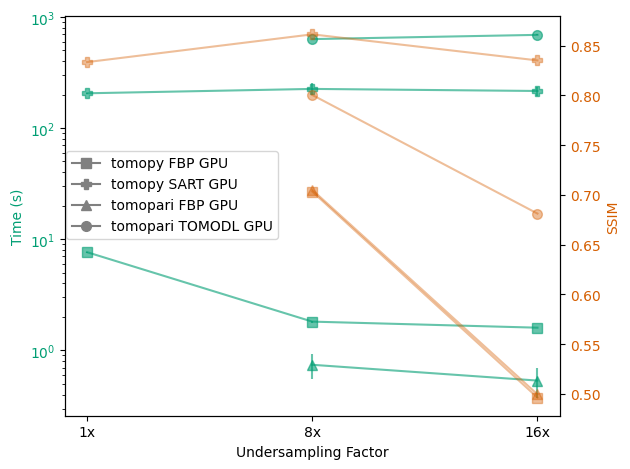

In [13]:
# I want time and quality metrics on the same plot using two y axes
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

_STEP_COLORS = {
    # 'time': '#56B4E9',  # Sky Blue
    # 'quality': '#E69F00',  # Orange
    'time': '#009E73', # Bluish Green
    'quality': '#D55E00'  # Vermillion (distinct from the green)
}

markersize = 7
fig, ax1 = plt.subplots()
# color = 'tab:blue'
color = _STEP_COLORS['time']
ax1.set_xlabel('Undersampling Factor')
ax1.set_ylabel('Time (s)', color=color)

recons = list(time_tomopy_fbp_gpu.keys())
y = [time_tomopy_fbp_gpu[c][0] for c in recons]
yerr = [time_tomopy_fbp_gpu[c][1] for c in recons]
ax1.errorbar(recons, y, yerr=yerr, color=_STEP_COLORS['time'], alpha=0.6, marker='s', ms=markersize, label='tomopy FBP GPU')

recons = list(time_tomopy_sart_gpu.keys())
y = [time_tomopy_sart_gpu[c][0] for c in recons]
yerr = [time_tomopy_sart_gpu[c][1] for c in recons]
ax1.errorbar(recons, y, yerr=yerr, color=_STEP_COLORS['time'], alpha=0.6, marker='P', ms=markersize, label='tomopy SART GPU')

recons = list(time_tomopari_fbp_gpu.keys())
y = [time_tomopari_fbp_gpu[c][0] for c in recons]
yerr = [time_tomopari_fbp_gpu[c][1] for c in recons]
ax1.errorbar(recons, y, yerr=yerr, color=_STEP_COLORS['time'], alpha=0.6, marker='^', ms=markersize, label='tomopari FBP GPU')

# recons = list(time_tomopari_fbp_cpu.keys())
# y = [time_tomopari_fbp_cpu[c][0] for c in recons]
# yerr = [time_tomopari_fbp_cpu[c][1] for c in recons]
# ax1.errorbar(recons, y, yerr=yerr, color=_STEP_COLORS['time'], alpha=0.6, marker='o', ms=markersize, label='tomopari FBP CPU')

recons = list(time_tomopari_tomodl_gpu.keys())
y = [time_tomopari_tomodl_gpu[c][0] for c in recons]
yerr = [time_tomopari_tomodl_gpu[c][1] for c in recons]
ax1.errorbar(recons, y, yerr=yerr, color=_STEP_COLORS['time'], alpha=0.6, marker='o', ms=markersize, label='tomopari TOMODL GPU')

# recons = list(time_tomopari_tomodl_cpu.keys())
# y = [time_tomopari_tomodl_cpu[c][0] for c in recons]
# yerr = [time_tomopari_tomodl_cpu[c][1] for c in recons]
# ax1.errorbar(recons, y, yerr=yerr, color=_STEP_COLORS['time'], alpha=0.6, marker='o', ms=markersize, label='tomopari TOMODL CPU')

ax1.tick_params(axis='y', labelcolor=color)

# split the y1 axis values
ax1.set_yscale('log')



ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = _STEP_COLORS['quality']
ax2.set_ylabel('SSIM', color=color)  # we already handled the x-label with ax1

recons = list(q_tomopy_fbp_gpu.keys())
y = [q_tomopy_fbp_gpu[c] for c in recons]
# yerr = [q_tomopy_fbp_gpu[c][1] for c in recons]
ax2.errorbar(recons, y, color=_STEP_COLORS['quality'], alpha=0.4, marker='s', ms=markersize, label='tomopy FBP GPU')

recons = list(q_tomopy_sart_gpu.keys())
y = [q_tomopy_sart_gpu[c] for c in recons]
# yerr = [q_tomopy_sart_gpu[c][1] for c in recons]
ax2.errorbar(recons, y, color=_STEP_COLORS['quality'], alpha=0.4, marker='P', ms=markersize, label='tomopy SART GPU')

recons = list(q_tomopari_fbp_gpu.keys())
y = [q_tomopari_fbp_gpu[c] for c in recons]
# yerr = [q_tomopari_fbp_gpu[c][1] for c in recons]
ax2.errorbar(recons, y, color=_STEP_COLORS['quality'], alpha=0.4, marker='^', ms=markersize, label='tomopari FBP GPU')

# recons = list(q_tomopari_fbp_cpu.keys())
# y = [q_tomopari_fbp_cpu[c] for c in recons]
# # yerr = [q_tomopari_fbp_cpu[c][1] for c in recons]
# ax2.errorbar(recons, y, color=_STEP_COLORS['quality'], alpha=0.4, marker='s', ms=markersize, label='tomopari FBP CPU')

recons = list(q_tomopari_tomodl_gpu.keys())
y = [q_tomopari_tomodl_gpu[c] for c in recons]
# yerr = [q_tomopari_tomodl_gpu[c][1] for c in recons]
ax2.errorbar(recons, y, color=_STEP_COLORS['quality'], alpha=0.4, marker='o', ms=markersize, label='tomopari TOMODL GPU')

# recons = list(q_tomopari_tomodl_cpu.keys())
# y = [q_tomopari_tomodl_cpu[c] for c in recons]
# # yerr = [q_tomopari_tomodl_cpu[c][1] for c in recons]
# ax2.errorbar(recons, y, color=_STEP_COLORS['quality'], alpha=0.4, marker='s', ms=markersize, label='tomopari TOMODL CPU')


custom_handles = [
    Line2D([0], [0], color='grey', marker='s', ms=markersize, linestyle='-', label='tomopy FBP GPU'),
    Line2D([0], [0], color='grey', marker='P', ms=markersize, linestyle='-', label='tomopy SART GPU'),
    Line2D([0], [0], color='grey', marker='^', ms=markersize, linestyle='-', label='tomopari FBP GPU'),
    Line2D([0], [0], color='grey', marker='o', ms=markersize, linestyle='-', label='tomopari TOMODL GPU'),
]

legend = ax1.legend(handles=custom_handles,
                    bbox_to_anchor=(0.445, 0., 0., 0.68))

ax2.tick_params(axis='y', labelcolor=color)
ax2.set_xticklabels(['1x', '8x', '16x'], rotation=45, ha='right')
fig.tight_layout()  # otherwise the right y-label is slightly clipped
# plt.title('Benchmarks of reconstruction methods')
plt.savefig('../fig_output/time_quality_comparison.png', dpi=300)
plt.show()